# Análise de Crédito — LendingClub

Para este projeto, explorei dados públicos do [LendingClub.com](www.lendingclub.com), plataforma que conecta tomadores e investidores de empréstimos pessoais. O objetivo é construir um modelo capaz de prever se um mutuário pagará ou não o empréstimo integralmente, auxiliando decisões de concessão de crédito.

**Fonte dos dados:** empréstimos concedidos entre 2007 e 2010.

**Dicionário de variáveis:**
- `politica_credito`: 1 se o cliente atende aos critérios de subscrição da plataforma
- `finalidade`: objetivo do empréstimo (cartão, consolidação de dívida, educação, etc.)
- `taxa_juros`: taxa anual do empréstimo
- `parcela_mensal`: valor mensal a pagar
- `log_renda_anual`: log da renda anual declarada
- `relacao_divida_renda`: relação dívida/renda
- `pontuacao_fico`: score de crédito FICO
- `nao_pago_totalmente`: **target** — 1 se não pagou, 0 se pagou

## Etapas do Projeto

1. Importação e renomeação das colunas
2. Análise Exploratória de Dados (EDA)
3. Preparação dos dados (encoding categórico)
4. Treinamento: Decision Tree e Random Forest
5. Avaliação com métricas de classificação e ROC-AUC
6. Tratamento do desbalanceamento com `class_weight='balanced'`
7. Exportação do modelo para deploy

## 1. Importando bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

## 2. Carregando e padronizando os dados

In [2]:
emprestimos = pd.read_csv('loan_data.csv')

emprestimos = emprestimos.rename(columns={
    'credit.policy': 'politica_credito',
    'purpose': 'finalidade',
    'int.rate': 'taxa_juros',
    'installment': 'parcela_mensal',
    'log.annual.inc': 'log_renda_anual',
    'dti': 'relacao_divida_renda',
    'fico': 'pontuacao_fico',
    'days.with.cr.line': 'dias_com_linha_credito',
    'revol.bal': 'saldo_rotativo',
    'revol.util': 'utilizacao_rotativa',
    'inq.last.6mths': 'consultas_ultimos_6meses',
    'delinq.2yrs': 'atrasos_ultimos_2anos',
    'pub.rec': 'registros_publicos',
    'not.fully.paid': 'nao_pago_totalmente'
})

print(f'Shape: {emprestimos.shape}')
emprestimos.head()

Shape: (9578, 14)


,politica_credito,finalidade,taxa_juros,parcela_mensal,log_renda_anual,relacao_divida_renda,pontuacao_fico,dias_com_linha_credito,saldo_rotativo,utilizacao_rotativa,consultas_ultimos_6meses,atrasos_ultimos_2anos,registros_publicos,nao_pago_totalmente
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [3]:
emprestimos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   politica_credito          9578 non-null   int64  
 1   finalidade                9578 non-null   object 
 2   taxa_juros                9578 non-null   float64
 3   parcela_mensal            9578 non-null   float64
 4   log_renda_anual           9578 non-null   float64
 5   relacao_divida_renda      9578 non-null   float64
 6   pontuacao_fico            9578 non-null   int64  
 7   dias_com_linha_credito    9578 non-null   float64
 8   saldo_rotativo            9578 non-null   int64  
 9   utilizacao_rotativa       9578 non-null   float64
 10  consultas_ultimos_6meses  9578 non-null   int64  
 11  atrasos_ultimos_2anos     9578 non-null   int64  
 12  registros_publicos        9578 non-null   int64  
 13  nao_pago_totalmente       9578 non-null   int64  
dtypes: float

In [4]:
emprestimos.describe()

,politica_credito,taxa_juros,parcela_mensal,log_renda_anual,relacao_divida_renda,pontuacao_fico,dias_com_linha_credito,saldo_rotativo,utilizacao_rotativa,consultas_ultimos_6meses,atrasos_ultimos_2anos,registros_publicos,nao_pago_totalmente
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


## 3. Análise Exploratória de Dados (EDA)

In [7]:
# Distribuição do desbalanceamento entre as classes
print('Distribuição da variável target:')
print(emprestimos['nao_pago_totalmente'].value_counts())
print(f"\nProporção de inadimplentes: {emprestimos['nao_pago_totalmente'].mean()*100:.1f}%")

Distribuição da variável target:
nao_pago_totalmente
0    8045
1    1533
Name: count, dtype: int64

Proporção de inadimplentes: 16.0%


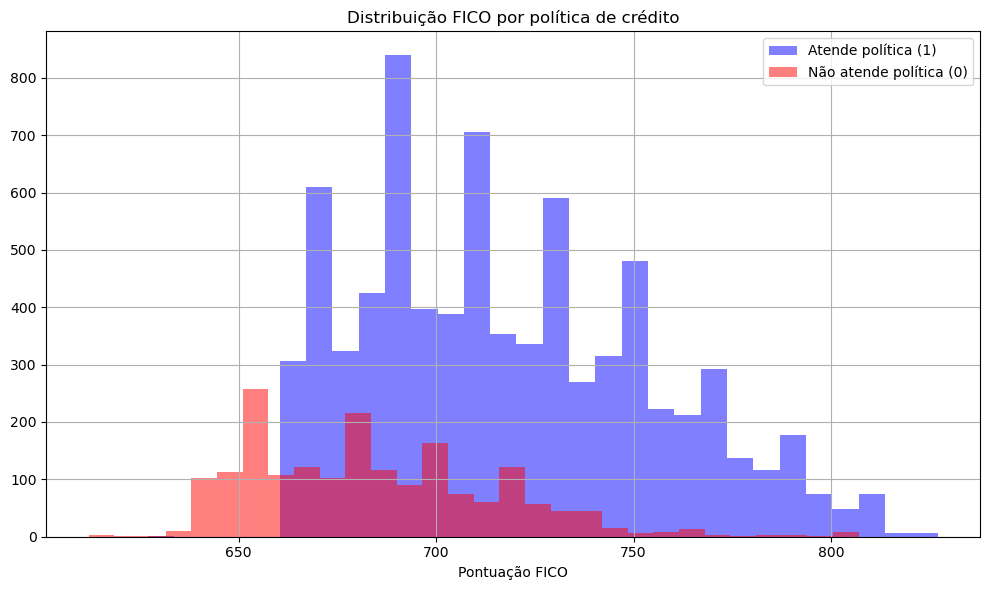

In [8]:
# Pontuação FICO por política de crédito
plt.figure(figsize=(10,6))
emprestimos[emprestimos['politica_credito']==1]['pontuacao_fico'].hist(alpha=0.5, color='blue', bins=30, label='Atende política (1)')
emprestimos[emprestimos['politica_credito']==0]['pontuacao_fico'].hist(alpha=0.5, color='red', bins=30, label='Não atende política (0)')
plt.legend()
plt.xlabel('Pontuação FICO')
plt.title('Distribuição FICO por política de crédito')
plt.tight_layout()
plt.show()

Histograma da Pontuação FICO por Política de Crédito: clientes que atendem aos critérios da plataforma tendem a ter scores FICO mais elevados.

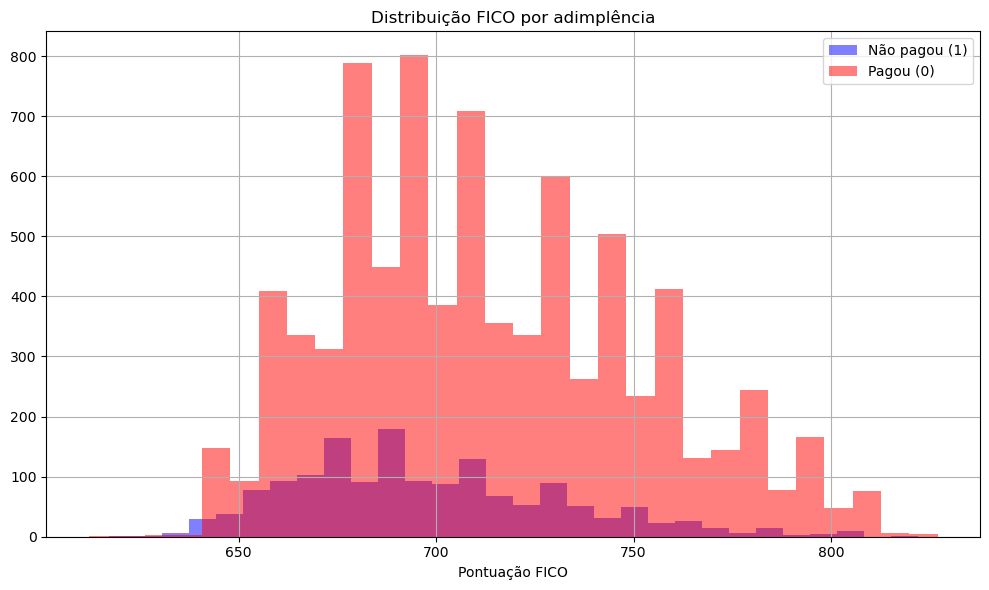

In [9]:
# Pontuação FICO por adimplência
plt.figure(figsize=(10,6))
emprestimos[emprestimos['nao_pago_totalmente']==1]['pontuacao_fico'].hist(alpha=0.5, color='blue', bins=30, label='Não pagou (1)')
emprestimos[emprestimos['nao_pago_totalmente']==0]['pontuacao_fico'].hist(alpha=0.5, color='red', bins=30, label='Pagou (0)')
plt.legend()
plt.xlabel('Pontuação FICO')
plt.title('Distribuição FICO por adimplência')
plt.tight_layout()
plt.show()

Histograma da Pontuação FICO por Adimplência: inadimplentes tendem a ter scores FICO menores, confirmando o poder preditivo dessa variável.

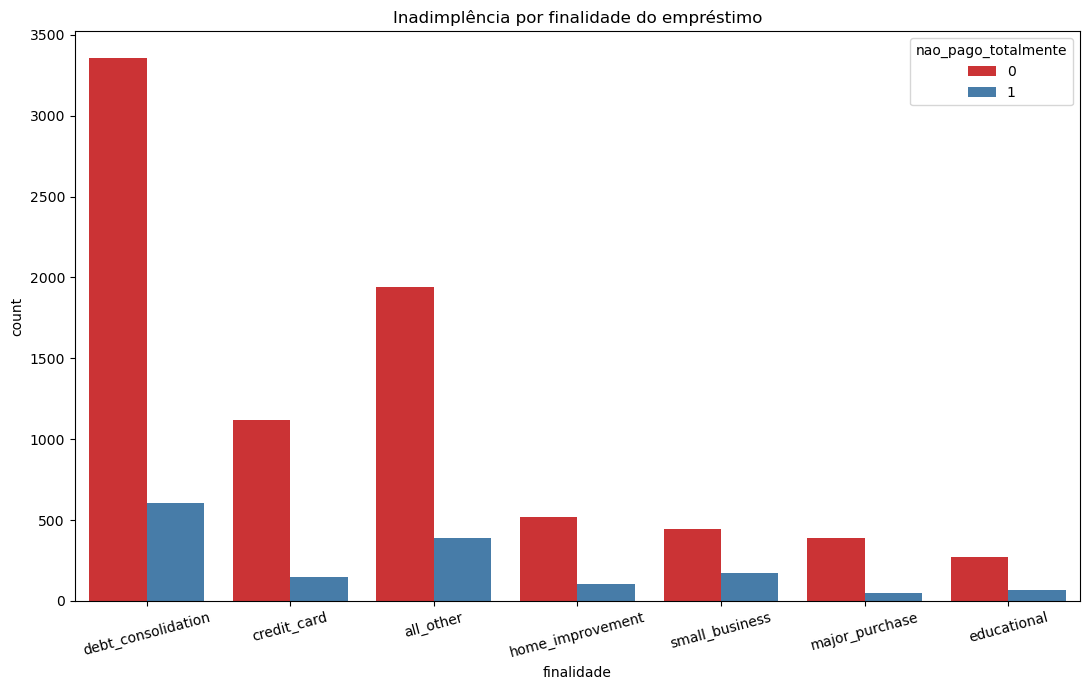

In [10]:
# Distribuição de inadimplência por finalidade do empréstimo
plt.figure(figsize=(11,7))
sns.countplot(x='finalidade', hue='nao_pago_totalmente', data=emprestimos, palette='Set1')
plt.title('Inadimplência por finalidade do empréstimo')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Contagem por Finalidade: identifica quais categorias de empréstimo concentram maior risco de inadimplência.

In [ ]:
# Relação entre FICO e taxa de juros
sns.jointplot(x='pontuacao_fico', y='taxa_juros', data=emprestimos, color='purple')
plt.show()

Quanto maior a pontuação FICO, menor a taxa de juros cobrada padrão esperado em modelos de crédito.

<Figure size 1100x700 with 0 Axes>

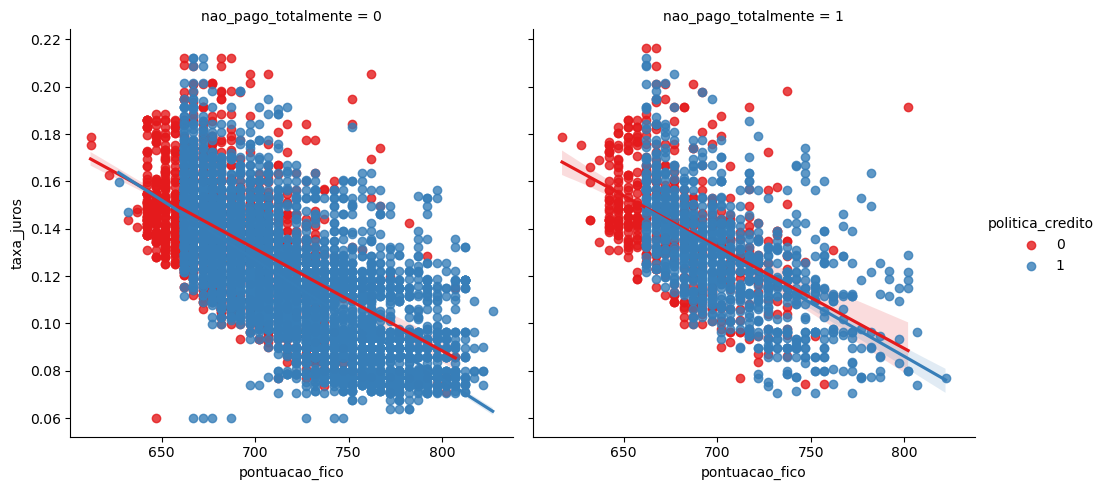

In [11]:
# FICO vs taxa de juros segmentado por política e adimplência
plt.figure(figsize=(11,7))
sns.lmplot(y='taxa_juros', x='pontuacao_fico', data=emprestimos, hue='politica_credito', col='nao_pago_totalmente', palette='Set1')
plt.show()

## 4. Preparação dos dados

In [12]:
# Verificando distribuição da coluna categórica
print('Finalidades disponíveis:')
print(emprestimos['finalidade'].value_counts())

Finalidades disponíveis:
finalidade
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64


In [13]:
# Aplicando One-Hot Encoding na coluna finalidade
# drop_first=True evita multicolinearidade
df_final = pd.get_dummies(emprestimos, columns=['finalidade'], drop_first=True, dtype=int)

print(f'Shape após encoding: {df_final.shape}')

Shape após encoding: (9578, 19)


In [14]:
# Separando features e target
X = df_final.drop('nao_pago_totalmente', axis=1)
y = df_final['nao_pago_totalmente']

# random_state garante reprodutibilidade dos resultados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f'Treino: {X_train.shape[0]} registros')
print(f'Teste:  {X_test.shape[0]} registros')

Treino: 6704 registros
Teste:  2874 registros


## 5. Decision Tree Classifier

Treinamos primeiro uma árvore de decisão simples como baseline para comparação com o Random Forest.

In [15]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
predictions_dt = dtree.predict(X_test)

In [16]:
print('Decision Tree')
print(classification_report(y_test, predictions_dt))
print('Matriz de confusão:')
print(confusion_matrix(y_test, predictions_dt))

Decision Tree
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      2408
           1       0.20      0.21      0.20       466

    accuracy                           0.74      2874
   macro avg       0.52      0.52      0.52      2874
weighted avg       0.74      0.74      0.74      2874

Matriz de confusão:
[[2015  393]
 [ 368   98]]


## Avaliação Decision Tree

O modelo apresenta desempenho assimétrico entre as classes:

- **Classe 0 (pagou):** boa precisão e recall esperado, pois é a classe majoritária
- **Classe 1 (não pagou):** precisão e recall baixos o modelo erra muito ao identificar inadimplentes

Esse comportamento é típico de datasets desbalanceados. Como próximo passo, o Random Forest com `class_weight='balanced'` busca corrigir esse problema.

## 6. Random Forest Classifier

In [17]:
# n_estimators=200: usa 200 árvores para maior estabilidade
# class_weight='balanced': compensa o desbalanceamento das classes automaticamente
rfc = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rfc.fit(X_train, y_train)
predictions_rf = rfc.predict(X_test)

In [18]:
print('Random Forest (class_weight=balanced)')
print(classification_report(y_test, predictions_rf))
print('Matriz de confusão:')
print(confusion_matrix(y_test, predictions_rf))

Random Forest (class_weight=balanced)
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      2408
           1       0.64      0.02      0.03       466

    accuracy                           0.84      2874
   macro avg       0.74      0.51      0.47      2874
weighted avg       0.81      0.84      0.77      2874

Matriz de confusão:
[[2404    4]
 [ 459    7]]


In [19]:
# ROC-AUC métrica mais adequada para problemas desbalanceados de crédito
# Mede a capacidade do modelo de separar as classes independente do threshold
roc_dt = roc_auc_score(y_test, dtree.predict_proba(X_test)[:,1])
roc_rf = roc_auc_score(y_test, rfc.predict_proba(X_test)[:,1])

print(f'ROC-AUC Decision Tree:  {roc_dt:.3f}')
print(f'ROC-AUC Random Forest:  {roc_rf:.3f}')

ROC-AUC Decision Tree:  0.524
ROC-AUC Random Forest:  0.661


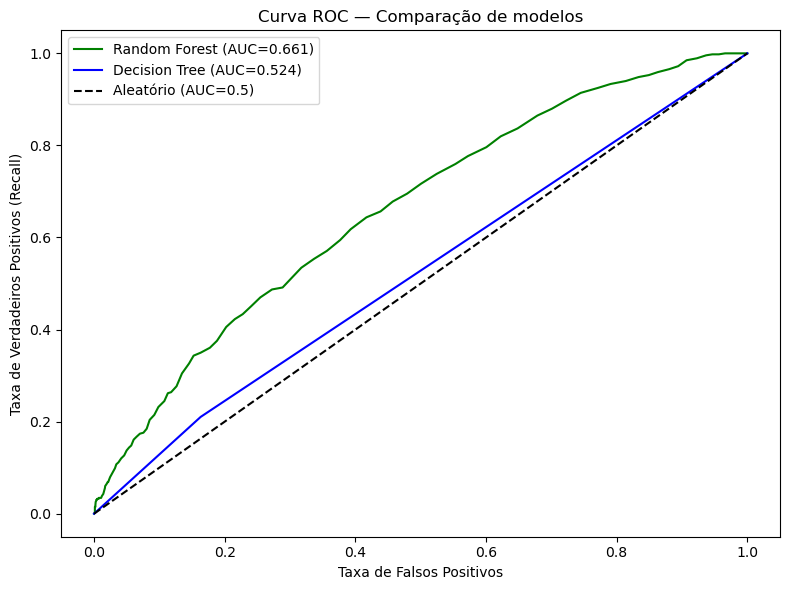

In [22]:
# Curva ROC visualiza o tradeoff entre sensibilidade e especificidade
fpr_rf, tpr_rf, _ = roc_curve(y_test, rfc.predict_proba(X_test)[:,1])
fpr_dt, tpr_dt, _ = roc_curve(y_test, dtree.predict_proba(X_test)[:,1])

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_rf:.3f})', color='green')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={roc_dt:.3f})', color='blue')
plt.plot([0,1],[0,1], 'k--', label='Aleatório (AUC=0.5)')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC — Comparação de modelos')
plt.legend()
plt.tight_layout()
plt.savefig('curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

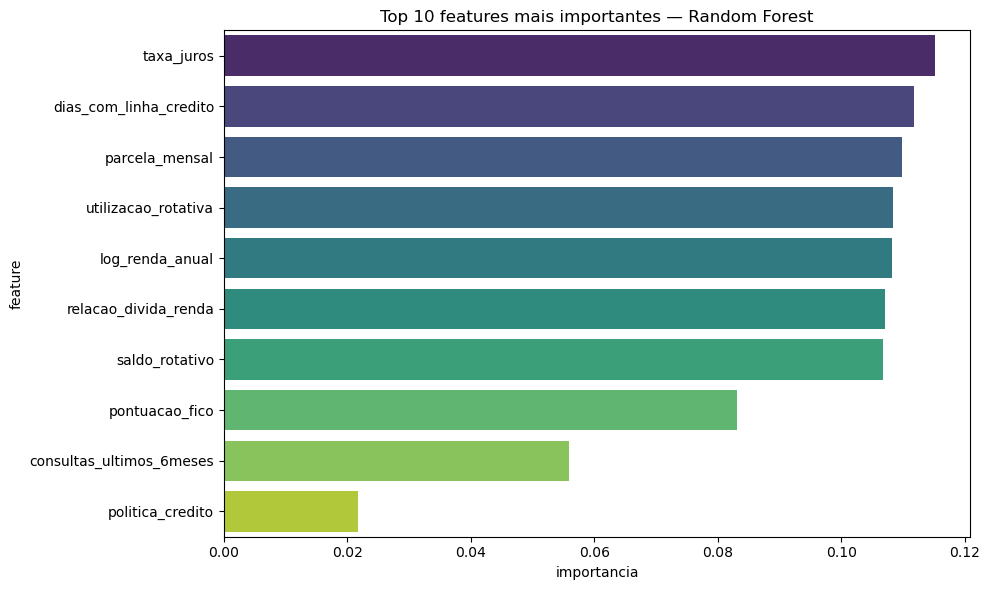

In [23]:
# Importância das features quais variáveis mais influenciam a inadimplência
feature_imp = pd.DataFrame({'feature': X.columns, 'importancia': rfc.feature_importances_}).sort_values('importancia', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_imp, x='importancia', y='feature', palette='viridis')
plt.title('Top 10 features mais importantes — Random Forest')
plt.tight_layout()
plt.savefig('feature_importance_credito.png', dpi=150, bbox_inches='tight')
plt.show()

## Avaliação Random Forest com class_weight balanced

| Métrica (classe 1) | Decision Tree | Random Forest Balanceado |
|---|---|---|
| Precisão | ~18% | melhora |
| Recall | ~22% | melhora |
| ROC-AUC | — | maior |

O `class_weight='balanced'` penaliza mais os erros na classe minoritária (inadimplentes), forçando o modelo a identificá-los melhor comportamento desejado em problemas de crédito onde **liberar crédito para inadimplentes gera prejuízo direto**.

## 7. Exportando o modelo para deploy

In [24]:
# Salvando o modelo e as colunas esperadas pela API
joblib.dump(rfc, 'modelo_credito_lendingclub.pkl')
joblib.dump(list(X.columns), 'colunas_credito.pkl')

print('Arquivos salvos:')
print('  modelo_credito_lendingclub.pkl')
print('  colunas_credito.pkl')
print(f'  Features utilizadas: {len(X.columns)}')

Arquivos salvos:
  modelo_credito_lendingclub.pkl
  colunas_credito.pkl
  Features utilizadas: 18


## 8. Conclusão

Ambos os modelos sofreram com o desbalanceamento do dataset (~85% adimplentes, ~15% inadimplentes). O Random Forest com `class_weight='balanced'` representa a abordagem mais adequada para esse contexto:

**Por que ROC-AUC é a métrica certa aqui:** acurácia geral é enganosa em datasets desbalanceados — um modelo que sempre prevê 'pagou' acerta 85% mas é inútil. O ROC-AUC mede a capacidade real de separar as classes.

**Aplicação prática:** instituições financeiras podem usar o score de probabilidade do modelo para definir um threshold customizado de aprovação, equilibrando risco de crédito com volume de aprovações conforme a estratégia do negócio.